## Libraries and Data

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set File Paths

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

In [3]:
# Load Dataset

energy_df = pd.read_csv(DATA_DIR / "processed" / "energy_household_with_target_step3.csv")

print("Dataset loaded successfully!")
print("Shape:", energy_df.shape)

energy_df.head()

Dataset loaded successfully!
Shape: (3599, 56)


,hhid,zone,state,lga,urca_cat,adult_count,members_under_18,members_18_30,members_31_55,members_over_55,...,fridge_monthly_kwh,ac_monthly_kwh,washing_machine_monthly_kwh,electric_cooker_monthly_kwh,thermal_appliance_monthly_kwh,air_cooler_monthly_kwh,estimated_monthly_kwh,supply_factor,estimated_monthly_kwh_adjusted,consumption_category
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,54.0,0.0,0.0,0.0,18.0,0.0,39.300,0.200000,39.300,High Consumption
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,12.375,0.250000,12.375,Moderate Consumption
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,0.0,0.0,0.0,0.0,18.0,0.0,51.225,0.500000,51.225,Very High Consumption
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,54.0,0.0,0.0,0.0,18.0,12.0,157.200,0.500000,157.200,Very High Consumption
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,0.0,0.0,0.0,0.0,18.0,0.0,4.875,0.208333,4.875,Moderate Consumption


In [4]:
# Check Target Column

print("Target column summary:")
print(energy_df['estimated_monthly_kwh'].describe())

print("\nMissing target values:")
print(energy_df['estimated_monthly_kwh'].isnull().sum())

Target column summary:
count    3599.000000
mean       39.859834
std        58.436122
min         0.000000
25%         4.800000
50%        19.162500
75%        49.612500
max       570.600000
Name: estimated_monthly_kwh, dtype: float64

Missing target values:
0


##### Create App-Friendly Feature Columns

In [5]:
# Create App-Friendly Feature Columns
#
# Create average AC usage hours feature
# In the dataset, AC usage hours were estimated during target creation.
# For households with AC, we use 4 hours as the default estimated usage.
# For households without AC, we use 0 hours.
energy_df['average_ac_usage_hours'] = np.where(
    energy_df['ac_count'] > 0,
    4,
    0
)

model_features = [
    'household_size',
    'number_of_rooms',
    'daily_supply_hours',
    'light_bulb_count',
    'fan_count',
    'television_count',
    'fridge_count',
    'ac_count',
    'average_ac_usage_hours'
]

target_column = 'estimated_monthly_kwh'

model_df = energy_df[model_features + [target_column]].copy()

model_df.head()

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


In [6]:
## Clean Modelling Dataset

# Convert all modelling columns to numeric
for col in model_features + [target_column]:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Replace infinite values with NaN
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Drop rows with missing values
model_df = model_df.dropna()

# Remove negative values if any exist
model_df = model_df[model_df[target_column] >= 0]

print("Clean modelling dataset shape:", model_df.shape)

model_df.head()

Clean modelling dataset shape: (3599, 10)


,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


In [7]:
# Check Feature Summary

model_df.describe()

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
count,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000
mean,7.037788,4.784940,7.067241,6.767435,1.886079,0.818839,0.431787,0.057794,0.231175,39.859834
std,5.048538,3.062783,5.815434,4.332175,1.931375,0.905465,0.495394,0.233386,0.933542,58.436122
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,3.000000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.800000
50%,6.000000,4.000000,6.000000,6.000000,2.000000,1.000000,0.000000,0.000000,0.000000,19.162500
75%,9.000000,6.000000,10.000000,8.000000,3.000000,1.000000,1.000000,0.000000,0.000000,49.612500
max,57.000000,30.000000,24.000000,43.000000,27.000000,12.000000,1.000000,1.000000,4.000000,570.600000


In [8]:
## Clean Modelling Dataset

# Convert all modelling columns to numeric
for col in model_features + [target_column]:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Replace infinite values with NaN
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Drop rows with missing values
model_df = model_df.dropna()

# Remove negative values if any exist
model_df = model_df[model_df[target_column] >= 0]

print("Clean modelling dataset shape:", model_df.shape)

model_df.head()

Clean modelling dataset shape: (3599, 10)


,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


## Feature Selection

In [9]:
# Define Features and Target

X = model_df[model_features]
y = model_df[target_column]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (3599, 9)
Target data shape: (3599,)


In [10]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2879, 9)
X_test shape: (720, 9)
y_train shape: (2879,)
y_test shape: (720,)


## Train Regression Models

We will compare four models:

Linear Regression
Decision Tree Regressor
Random Forest Regressor
Gradient Boosting Regressor

Linear Regression - Justus

In [11]:
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 0.18, 0.09, 4.83,...,19.3 , 5.06,20.22]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['household_size','number_of_rooms','daily_supply_hours',..., 'fridge_count','ac_count','average_ac_usage_hours']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-30.66
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [12]:
# Make Predictions on the test data
y_pred_lr = lr_model.predict(X_test)

In [13]:
# Evaluate Linear Regression Model
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)



Linear Regression Results
MAE: 18.19393703237961
MSE: 783.7279424612938
RMSE: 27.995141408131765
R² Score: 0.7727413251246809


Random Forest Model - Habiba

In [14]:
# Train Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
        random_state=42
        )

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [15]:
# Make predictions on the test data

y_pred_rf = rf_model.predict(X_test)

In [16]:
# Evaluate Random Forest Regressor

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 8.994154998335286
MSE: 341.40014819458105
RMSE: 18.477016755812638
R² Score: 0.9010037270876433


GRADIENT BOOSTING - EBUBECHUKWU

Gradient Boosting Results
------------------------------
MAE      : 8.7309
MSE      : 271.4642
RMSE     : 16.4762
R² Score : 0.9213

Feature Importance
                  Feature  Importance
2      daily_supply_hours    0.454087
7                ac_count    0.140885
4               fan_count    0.139975
6            fridge_count    0.136484
8  average_ac_usage_hours    0.063687
5        television_count    0.048400
3        light_bulb_count    0.010946
1         number_of_rooms    0.002788
0          household_size    0.002748


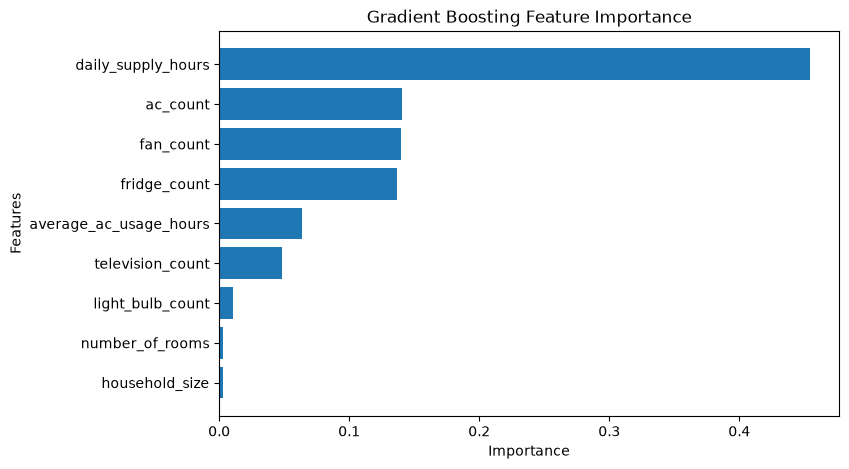


Gradient Boosting model saved successfully!


In [17]:
# ==========================================
# Gradient Boosting Regressor
# ==========================================

# Train the model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-" * 30)
print(f"MAE      : {gb_mae:.4f}")
print(f"MSE      : {gb_mse:.4f}")
print(f"RMSE     : {gb_rmse:.4f}")
print(f"R² Score : {gb_r2:.4f}")

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Save the model
joblib.dump(gb_model, MODEL_DIR / "gradient_boosting_energy_model.pkl")
print("\nGradient Boosting model saved successfully!")

## Unsupervised Learning

## Libraries and Data

In [18]:
# Import Libraries

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib


In [19]:
# Set File Paths

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

In [20]:
# Load Dataset

energy_df = pd.read_csv(DATA_DIR / "processed" / "energy_household_with_target_step3.csv")

print("Dataset loaded successfully!")
print("Shape:", energy_df.shape)

energy_df.head()

Dataset loaded successfully!
Shape: (3599, 56)


,hhid,zone,state,lga,urca_cat,adult_count,members_under_18,members_18_30,members_31_55,members_over_55,...,fridge_monthly_kwh,ac_monthly_kwh,washing_machine_monthly_kwh,electric_cooker_monthly_kwh,thermal_appliance_monthly_kwh,air_cooler_monthly_kwh,estimated_monthly_kwh,supply_factor,estimated_monthly_kwh_adjusted,consumption_category
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,54.0,0.0,0.0,0.0,18.0,0.0,39.300,0.200000,39.300,High Consumption
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,12.375,0.250000,12.375,Moderate Consumption
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,0.0,0.0,0.0,0.0,18.0,0.0,51.225,0.500000,51.225,Very High Consumption
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,54.0,0.0,0.0,0.0,18.0,12.0,157.200,0.500000,157.200,Very High Consumption
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,0.0,0.0,0.0,0.0,18.0,0.0,4.875,0.208333,4.875,Moderate Consumption


In [21]:
# Create Clustering Features

# Create average AC usage hours feature
energy_df['average_ac_usage_hours'] = np.where(
    energy_df['ac_count'] > 0,
    4,
    0
)

clustering_features = [
    'household_size',
    'number_of_rooms',
    'daily_supply_hours',
    'light_bulb_count',
    'fan_count',
    'television_count',
    'fridge_count',
    'ac_count',
    'average_ac_usage_hours',
    'estimated_monthly_kwh'
]

# Keep only columns that exist
clustering_features = [
    col for col in clustering_features
    if col in energy_df.columns
]

cluster_df = energy_df[clustering_features].copy()

cluster_df.head()

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


In [22]:
# Clean Clustering Dataset

for col in clustering_features:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors='coerce')

cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)

cluster_df = cluster_df.dropna()

print("Clean clustering dataset shape:", cluster_df.shape)

cluster_df.head()

Clean clustering dataset shape: (3599, 10)


,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


##### Scale the Features

In [23]:
# Scale Features

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

cluster_scaled[:5]

array([[ 2.1716655 ,  1.04986425, -0.52750445,  1.90059444,  3.16601918,
         1.30466137,  1.14715248, -0.24766679, -0.24766679, -0.0095816 ],
       [ 0.58682802,  1.37641005, -0.18354421,  1.20800548, -0.45884544,
         0.20010332, -0.8717237 , -0.24766679, -0.24766679, -0.47040515],
       [-0.20559072,  0.07022685,  0.84833649, -0.17717243,  0.05899236,
         0.20010332, -0.8717237 , -0.24766679, -0.24766679,  0.19451574],
       [ 0.58682802,  1.70295585,  0.84833649,  3.05490936,  2.13034357,
         0.20010332,  1.14715248, -0.24766679, -0.24766679,  2.00828645],
       [-0.20559072, -0.58286475, -0.35552433, -0.86976138, -0.97668325,
        -0.90445473, -0.8717237 , -0.24766679, -0.24766679, -0.59876826]])

##### Find Best Number of Clusters with Elbow Method

K-MEANS CLUSTERING - EBUBECHUKWU

In [24]:
# K-Means Clustering

# Import the required libraries

# Create the K-Means clustering model
kmeans = KMeans(
    n_clusters=3,      # Number of clusters
    random_state=42
)

# Perform clustering on the dataset
clusters = kmeans.fit_predict(X)

# Display the cluster labels
print("Cluster Labels:")
print(clusters)

# Display the cluster centroids
print("\nCluster Centroids:")
print(kmeans.cluster_centers_)

Cluster Labels:
[0 0 1 ... 2 0 0]

Cluster Centroids:
[[14.63955638  8.42144177  5.33086876 12.04251386  3.16081331  1.28465804
   0.41219963  0.06099815  0.24399261]
 [ 5.80633374  4.3593179  15.47381242  6.84774665  2.14007308  1.01583435
   0.62362972  0.14494519  0.57978076]
 [ 5.65131873  4.06168976  4.40187751  5.4622262   1.48457756  0.63388467
   0.36611533  0.02503353  0.10013411]]


## HIERARCHICAL_CLUSTERING_Chiemezie

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

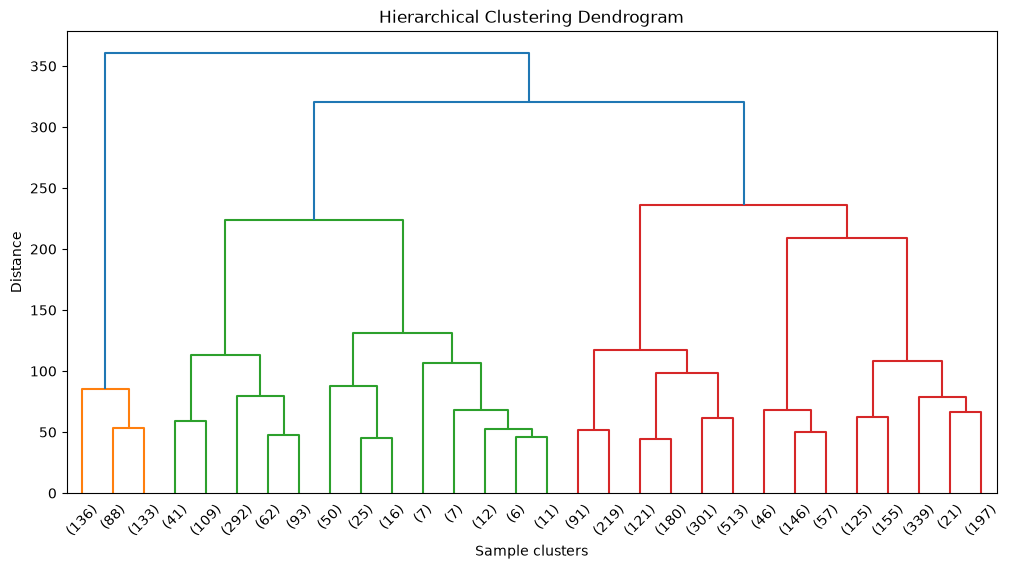

In [26]:
# Reusing the same scaled feature matrix (X) from the K-Means section above,
# so results are comparable across both clustering methods

linked = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample clusters")
plt.ylabel("Distance")
plt.show()

In [27]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X)

print("Cluster Labels:")
print(hc_labels)

Cluster Labels:
[2 0 0 ... 0 0 2]


In [28]:
import pandas as pd

comparison = pd.DataFrame({
    'kmeans_cluster': clusters,      # from your teammate's cell above
    'hierarchical_cluster': hc_labels
})

# Cross-tab shows how much the two methods agree on groupings
pd.crosstab(comparison['kmeans_cluster'], comparison['hierarchical_cluster'])

hierarchical_cluster,0,1,2
kmeans_cluster,,,
0,180,0,361
1,451,357,13
2,1880,0,357


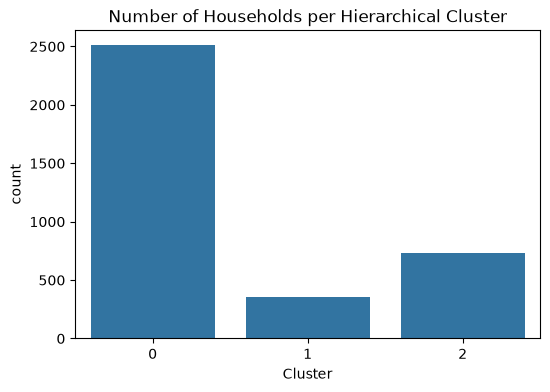

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(x=hc_labels)
plt.title("Number of Households per Hierarchical Cluster")
plt.xlabel("Cluster")
plt.show()

Evaluating Clustering performance - Habiba

In [30]:
# Evaluate Clustering Performance


# Calculate Silhouette Score for K-Means
kmeans_silhouette = silhouette_score(X, clusters)

# Calculate Silhouette Score for Hierarchical Clustering
hierarchical_silhouette = silhouette_score(X, hc_labels)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))
print("Hierarchical Clustering Silhouette Score:", round(hierarchical_silhouette, 4))

K-Means Silhouette Score: 0.3208
Hierarchical Clustering Silhouette Score: 0.2613


### Clustering Evaluation

The Silhouette Score was used to compare the quality of the clusters produced by K-Means and Hierarchical Clustering. K-Means achieved a score of 0.3208, while Hierarchical Clustering achieved 0.2613. Since a higher Silhouette Score indicates better-defined and more separated clusters, K-Means produced the better-separated household segments for this dataset.

In [31]:
# Add K-Means cluster labels to the original feature data
cluster_profile = model_df[model_features].copy()
cluster_profile['kmeans_cluster'] = clusters

# Calculate the average feature values for each cluster
kmeans_profile = cluster_profile.groupby('kmeans_cluster').mean()

kmeans_profile

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours
kmeans_cluster,,,,,,,,,
0,14.639556,8.421442,5.330869,12.042514,3.160813,1.284658,0.412200,0.060998,0.243993
1,5.806334,4.359318,15.473812,6.847747,2.140073,1.015834,0.623630,0.144945,0.579781
2,5.651319,4.061690,4.401878,5.462226,1.484578,0.633885,0.366115,0.025034,0.100134


In [32]:
# Count households in each K-Means cluster
cluster_sizes = pd.Series(clusters).value_counts().sort_index()

print("Number of households per cluster:")
print(cluster_sizes)

Number of households per cluster:
0     541
1     821
2    2237
Name: count, dtype: int64


In [33]:
# Add estimated monthly energy consumption to the cluster profile

cluster_profile['estimated_monthly_kwh'] = y.values

# Calculate the average energy consumption per cluster
energy_by_cluster = (
    cluster_profile
        .groupby('kmeans_cluster')['estimated_monthly_kwh']
            .mean()
                .sort_values()
                )

print("Average estimated monthly energy consumption by cluster:")
print(energy_by_cluster)

Average estimated monthly energy consumption by cluster:
kmeans_cluster
2    17.823539
0    44.480483
1    96.857910
Name: estimated_monthly_kwh, dtype: float64


In [34]:
consumption_labels = {
        2: "Low Consumption",
            0: "Moderate Consumption",
                1: "High Consumption"
                }

In [35]:
cluster_profile['consumption_category'] = (
        cluster_profile['kmeans_cluster'].map(consumption_labels)
        )

cluster_profile.head()


,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,kmeans_cluster,estimated_monthly_kwh,consumption_category
0,18,8,4.0,15,8,2,1,0,0,0,39.300,Moderate Consumption
1,10,9,6.0,12,1,1,0,0,0,0,12.375,Moderate Consumption
2,6,5,12.0,6,2,1,0,0,0,1,51.225,High Consumption
3,10,10,12.0,20,6,1,1,0,0,0,157.200,Moderate Consumption
4,6,3,5.0,3,0,0,0,0,0,2,4.875,Low Consumption


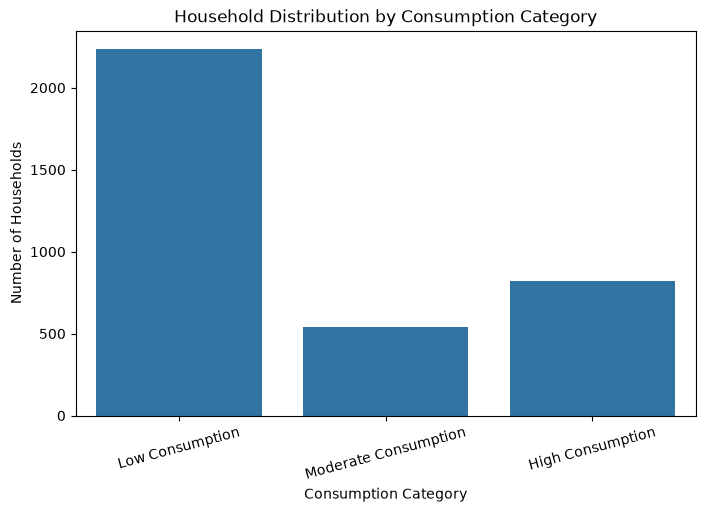

In [36]:
# Visualize household consumption categories

plt.figure(figsize=(8, 5))

sns.countplot(
    data=cluster_profile,
        x='consumption_category',
            order=[
                    'Low Consumption',
                            'Moderate Consumption',
                                    'High Consumption'
                                        ]
                                        )

plt.title("Household Distribution by Consumption Category")
plt.xlabel("Consumption Category")
plt.ylabel("Number of Households")
plt.xticks(rotation=15)
plt.show()

In [37]:
# Summarize the consumption categories

category_summary = (
    cluster_profile
        .groupby('consumption_category')
            .agg(
                    number_of_households=('consumption_category', 'size'),
                            average_monthly_kwh=('estimated_monthly_kwh', 'mean')
                                )
                                    .reindex([
                                            'Low Consumption',
                                                    'Moderate Consumption',
                                                            'High Consumption'
                                                                ])
                                                                )

category_summary

,number_of_households,average_monthly_kwh
consumption_category,,
Low Consumption,2237,17.823539
Moderate Consumption,541,44.480483
High Consumption,821,96.857910
